
### Analise exploratória dos dados, onde serão feitas as seguintes etapas:
1. Carregamento dos dados
2. Verificação de valores nulos
3. Análise de distribuição das variáveis
4. Análise de correlação entre as variáveis
5. Visualização dos dados

#### Bibliotecas 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Configurações para visualização

In [3]:
# Configurações
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

#### Carregar os dados

In [4]:
df = pd.read_excel('../data/raw/SerasaCredito - Case.xlsx')
n,m = df.shape
print(f"Number of rows: {n}, Number of columns: {m}")
df.head()

Number of rows: 107821, Number of columns: 11


,data,fx_score_de_credito,fx_de_renda,Negativado,faixa_etaria,total_users_simulando,creditType,usuario_elegivel,possui_oferta,convercao_efetiva,receita_gerada
0,2025-02-03,301-400,0-1600,True,0-20,490,digital-account,360.0,359.0,17.0,19.5
1,2025-02-03,301-400,0-1600,True,0-20,490,personal-loan-fgts,20.0,11.0,5.0,6.0
2,2025-02-03,301-400,0-1600,True,0-20,490,personal-loan,66.0,43.0,10.0,0.0
3,2025-02-03,301-400,0-1600,True,0-20,490,vehicle-guarantee-loan,2.0,0.0,0.0,0.0
4,2025-02-14,701-800,4001-5000,False,31-40,7196,personal-loan-fgts,40.0,2.0,0.0,0.0


In [5]:
df.tail()

,data,fx_score_de_credito,fx_de_renda,Negativado,faixa_etaria,total_users_simulando,creditType,usuario_elegivel,possui_oferta,convercao_efetiva,receita_gerada
107816,2025-02-05,801-900,5001-6000,True,31-40,1,personal-loan,1.0,1.0,0.0,0.0
107817,2025-02-02,801-900,7001-8000,False,0-20,2,credit-card,2.0,0.0,0.0,0.0
107818,2025-02-16,101-200,8001-9000,False,51-60,2,credit-card,1.0,0.0,0.0,0.0
107819,2025-02-16,101-200,8001-9000,False,51-60,2,digital-account,1.0,1.0,0.0,0.0
107820,2025-02-12,0-100,2001-3000,False,61-70,1,NaN,0.0,0.0,0.0,0.0


In [6]:
df.dtypes

data                     datetime64[ns]
fx_score_de_credito              object
fx_de_renda                      object
Negativado                         bool
faixa_etaria                     object
total_users_simulando             int64
creditType                       object
usuario_elegivel                float64
possui_oferta                   float64
convercao_efetiva               float64
receita_gerada                  float64
dtype: object

#### Verificando valores nulos

In [7]:
# Ocorrências de valores nulos
df.isnull().sum()

data                        0
fx_score_de_credito         0
fx_de_renda                 0
Negativado                  0
faixa_etaria                0
total_users_simulando       0
creditType               2170
usuario_elegivel            0
possui_oferta               0
convercao_efetiva           0
receita_gerada              0
dtype: int64

In [8]:
# Porcentagem de valores nulos
df.isnull().sum()/n

data                     0.000000
fx_score_de_credito      0.000000
fx_de_renda              0.000000
Negativado               0.000000
faixa_etaria             0.000000
total_users_simulando    0.000000
creditType               0.020126
usuario_elegivel         0.000000
possui_oferta            0.000000
convercao_efetiva        0.000000
receita_gerada           0.000000
dtype: float64

In [9]:
# porcentagem baixa de valores nulos

In [10]:
df[df['creditType'].isnull()].describe()

,data,total_users_simulando,usuario_elegivel,possui_oferta,convercao_efetiva,receita_gerada
count,2170,2170.000000,2170.0,2170.0,2170.0,2170.0
mean,2025-02-14 09:41:58.341013760,1.547926,0.0,0.0,0.0,0.0
min,2025-02-01 00:00:00,1.000000,0.0,0.0,0.0,0.0
25%,2025-02-07 00:00:00,1.000000,0.0,0.0,0.0,0.0
50%,2025-02-14 00:00:00,1.000000,0.0,0.0,0.0,0.0
75%,2025-02-21 00:00:00,2.000000,0.0,0.0,0.0,0.0
max,2025-02-28 00:00:00,11.000000,0.0,0.0,0.0,0.0
std,NaN,1.130392,0.0,0.0,0.0,0.0


Como as variáveis numéricas apresentam apenas valores nulos quando o tipo de crédito é nulo, é possível concluir que esses 2% de registros são ruídos e não ajudam em nada na construção de um modelo preditivo. Portanto, é possível remover esses registros sem perder informação relevante.

#### Removendo nulos

In [11]:
df = df[~df['creditType'].isnull()]

In [12]:
# Ocorrências de valores nulos
df.isnull().sum()

data                     0
fx_score_de_credito      0
fx_de_renda              0
Negativado               0
faixa_etaria             0
total_users_simulando    0
creditType               0
usuario_elegivel         0
possui_oferta            0
convercao_efetiva        0
receita_gerada           0
dtype: int64

#### Exploratory Data Analysis (EDA)

##### Estatísticas descritivas

In [13]:
df.describe()

,data,total_users_simulando,usuario_elegivel,possui_oferta,convercao_efetiva,receita_gerada
count,105651,105651.000000,105651.000000,105651.000000,105651.000000,105651.000000
mean,2025-02-14 15:43:55.829286912,1602.411127,368.457913,171.628106,6.644130,25.837919
min,2025-02-01 00:00:00,1.000000,1.000000,0.000000,0.000000,0.000000
25%,2025-02-08 00:00:00,72.000000,3.000000,1.000000,0.000000,0.000000
50%,2025-02-15 00:00:00,393.000000,14.000000,8.000000,0.000000,0.000000
75%,2025-02-22 00:00:00,1346.000000,117.000000,65.000000,3.000000,7.500000
max,2025-02-28 00:00:00,59394.000000,63865.000000,14003.000000,853.000000,3087.000000
std,NaN,4110.239767,1881.459197,655.690384,28.838784,104.397305


In [14]:
len(df['data'].unique())

28

É possível observar que é uma base diária ofertas de crédito que vai de 2025-02-01 a 2025-02-28, ou seja, um mês de dados.

In [15]:
df[df['total_users_simulando']>50000].head()

,data,fx_score_de_credito,fx_de_renda,Negativado,faixa_etaria,total_users_simulando,creditType,usuario_elegivel,possui_oferta,convercao_efetiva,receita_gerada
8539,2025-02-10,501-600,0-1600,False,21-30,50987,credit-card,54493.0,9095.0,234.0,1963.5
8540,2025-02-10,501-600,0-1600,False,21-30,50987,personal-loan,3452.0,1900.0,352.0,583.5
8541,2025-02-10,501-600,0-1600,False,21-30,50987,payroll-loan,8.0,7.0,0.0,0.0
8542,2025-02-10,501-600,0-1600,False,21-30,50987,vehicle-guarantee-loan,345.0,139.0,22.0,343.5
8543,2025-02-10,501-600,0-1600,False,21-30,50987,digital-account,9290.0,9120.0,208.0,240.0


Aparentemente, parece ter outliers que jogam os valores para cima. Vamos investigar melhor isso depois. Mas vale observar que a conversão do quatile 75% é baixa, o que pode indicar que a maioria dos valores estão concentrados em uma faixa baixa, e os outliers estão puxando a média para cima.

#### quais são os tipos de crédito?

In [16]:
for credite_type in df['creditType'].unique():
    print(credite_type)

digital-account
personal-loan-fgts
personal-loan
vehicle-guarantee-loan
credit-card
payroll-loan
home-equity


#### Tipos de Produtos de Crédito - Serasa

| creditType                    | Nome em Português                  | Descrição                                                                 | Perfil Típico de Cliente                          | Característica Principal |
|-------------------------------|------------------------------------|---------------------------------------------------------------------------|---------------------------------------------------|--------------------------|
| **digital-account**           | Conta Digital                      | Conta corrente 100% digital para movimentação diária                      | Jovens e pessoas que buscam simplicidade          | Baixo risco, alta volume |
| **personal-loan**             | Empréstimo Pessoal                 | Empréstimo sem garantia específica para qualquer finalidade               | Público geral que precisa de crédito rápido       | Médio-alto risco         |
| **personal-loan-fgts**        | Empréstimo Pessoal com FGTS        | Empréstimo com garantia do saldo do FGTS (Saque-Aniversário)              | Trabalhadores CLT com saldo no FGTS               | Juros mais baixos        |
| **payroll-loan**              | Empréstimo Consignado              | Empréstimo com desconto direto em folha de pagamento                      | Servidores, aposentados e CLT                     | Baixo risco, alta conversão |
| **vehicle-guarantee-loan**    | Empréstimo com Garantia de Veículo | Empréstimo com o veículo como garantia (refinanciamento)                  | Pessoas que possuem veículo quitado               | Garantia real            |
| **home-equity**               | Empréstimo com Garantia de Imóvel  | Empréstimo com imóvel como garantia (maiores valores)                     | Proprietários de imóveis                          | Baixo risco, alto valor  |
| **credit-card**               | Cartão de Crédito                  | Cartão de crédito tradicional com limite rotativo                        | Consumidores que parcelam compras                 | Alto risco rotativo      |

In [17]:
#### Quaos são as faixa etárias?
for faixa_etaria in df['faixa_etaria'].unique():
    print(faixa_etaria)

0-20
31-40
41-50
21-30
51-60
61-70
71-80
80+


Faixas de idade são de 0-20, depois faixas de 10 em 10 até chegar em 80 ou superior.

É possível pensar em distribuição de crédito por faixa etária

#### Faixas de renda

In [18]:
for faixa_renda in df['fx_de_renda'].unique():
    print(faixa_renda)

0-1600
4001-5000
1601-2000
7001-8000
3001-4000
9001+
6001-7000
2001-3000
5001-6000
8001-9000


Faixas de renda são de 0-1600, depois faixas de 1000 em 1000 até chegar em 9.000 ou superior.

### Analisando no $\mathbb{R}^1$ (Big Numbers)

In [39]:
df.dtypes

data                     datetime64[ns]
fx_score_de_credito              object
fx_de_renda                      object
Negativado                         bool
faixa_etaria                     object
total_users_simulando             int64
creditType                       object
usuario_elegivel                float64
possui_oferta                   float64
convercao_efetiva               float64
receita_gerada                  float64
dtype: object

In [81]:
# ==================== R1 - VISÃO GERAL (BIG NUMBERS + TAXAS) ====================

# Totais absolutos
totais = df[['usuario_elegivel', 'possui_oferta', 'convercao_efetiva', 'receita_gerada']].sum()

# Taxas do funil
taxa_elegibilidade = (totais['usuario_elegivel'] / df['total_users_simulando'].sum()) * 100
taxa_oferta        = (totais['possui_oferta'] / totais['usuario_elegivel']) * 100
taxa_conversao     = (totais['convercao_efetiva'] / totais['possui_oferta']) * 100
ticket_medio       = totais['receita_gerada'] / totais['convercao_efetiva'] if totais['convercao_efetiva'] > 0 else 0

# Por dia
dias_analisados = len(df['data'].unique())

print("=== R1 - RESUMO GERAL - FEVEREIRO 2025 ===\n")
print(f"Período analisado: {dias_analisados} dias\n")

print("VOLUMES TOTAIS:")
print(f"Usuários Elegíveis     : {totais['usuario_elegivel']:,.0f}")
print(f"Ofertas Realizadas     : {totais['possui_oferta']:,.0f}")
print(f"Conversões Efetivas    : {totais['convercao_efetiva']:,.0f}")
print(f"Receita Gerada         : R$ {totais['receita_gerada']:,.0f}\n")

print("TAXAS DO FUNIL:")
print(f"Taxa de Elegibilidade  : {taxa_elegibilidade:.2f}%")
print(f"Taxa de Oferta         : {taxa_oferta:.2f}%")
print(f"Taxa de Conversão      : {taxa_conversao:.2f}%")
print(f"Ticket Médio por Conversão : R$ {ticket_medio:,.2f}\n")

print("MÉDIAS POR DIA:")
print(f"Elegíveis por dia      : {totais['usuario_elegivel']/dias_analisados:,.0f}")
print(f"Ofertas por dia        : {totais['possui_oferta']/dias_analisados:,.0f}")
print(f"Conversões por dia     : {totais['convercao_efetiva']/dias_analisados:,.0f}")
print(f"Receita por dia        : R$ {totais['receita_gerada']/dias_analisados:,.0f}")

=== R1 - RESUMO GERAL - FEVEREIRO 2025 ===

Período analisado: 28 dias

VOLUMES TOTAIS:
Usuários Elegíveis     : 38,927,947
Ofertas Realizadas     : 18,132,681
Conversões Efetivas    : 701,959
Receita Gerada         : R$ 2,729,802

TAXAS DO FUNIL:
Taxa de Elegibilidade  : 22.99%
Taxa de Oferta         : 46.58%
Taxa de Conversão      : 3.87%
Ticket Médio por Conversão : R$ 3.89

MÉDIAS POR DIA:
Elegíveis por dia      : 1,390,284
Ofertas por dia        : 647,596
Conversões por dia     : 25,070
Receita por dia        : R$ 97,493


### Analisando no $\mathbb{R}^1$ ao longo do tempo (Big Numbers Temporais + Correlação)

#### Analisar KPIS mais importantes: Taxa de conversão e receita diária

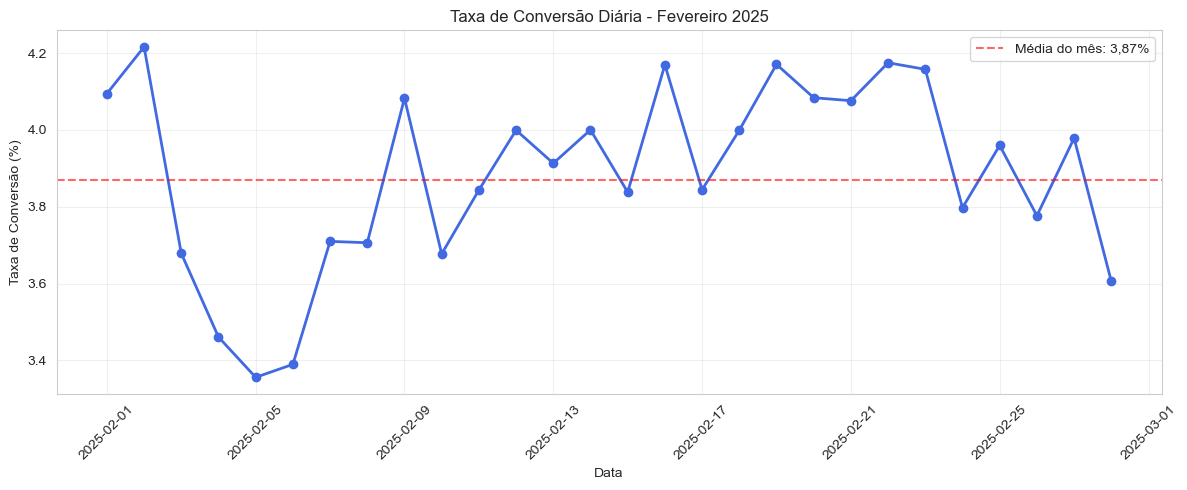

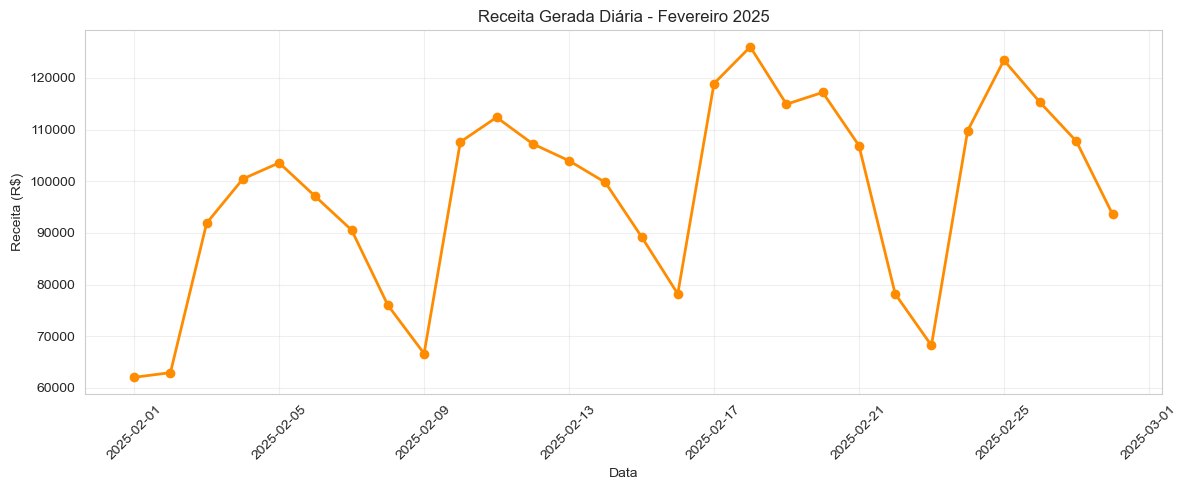

In [61]:
# Agrupando por dia
df_daily = df.groupby('data').agg({
    'possui_oferta': 'sum',
    'convercao_efetiva': 'sum',
    'receita_gerada': 'sum'
}).reset_index()

# Calculando taxas e ticket médio diário
df_daily['taxa_convercao'] = (df_daily['convercao_efetiva'] / df_daily['possui_oferta']) * 100
df_daily['ticket_medio']   = df_daily['receita_gerada'] / df_daily['convercao_efetiva']

# Plot 1 - Taxa de Conversão ao longo do tempo
plt.figure(figsize=(12, 5))
plt.plot(df_daily['data'], df_daily['taxa_convercao'], marker='o', linewidth=2, color='royalblue')
plt.title('Taxa de Conversão Diária - Fevereiro 2025')
plt.xlabel('Data')
plt.ylabel('Taxa de Conversão (%)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.axhline(y=3.87, color='red', linestyle='--', alpha=0.6, label='Média do mês: 3,87%')
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2 - Receita Diária (para ver o impacto)
plt.figure(figsize=(12, 5))
plt.plot(df_daily['data'], df_daily['receita_gerada'], marker='o', linewidth=2, color='darkorange')
plt.title('Receita Gerada Diária - Fevereiro 2025')
plt.xlabel('Data')
plt.ylabel('Receita (R$)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Analisar a demanda, receita e conversão ao longo do tempo (análise temporal)

📊 Correlação entre variáveis diárias:
                   convercao_efetiva  receita_gerada  ticket_medio
convercao_efetiva              1.000           0.922        -0.274
receita_gerada                 0.922           1.000         0.115
ticket_medio                  -0.274           0.115         1.000


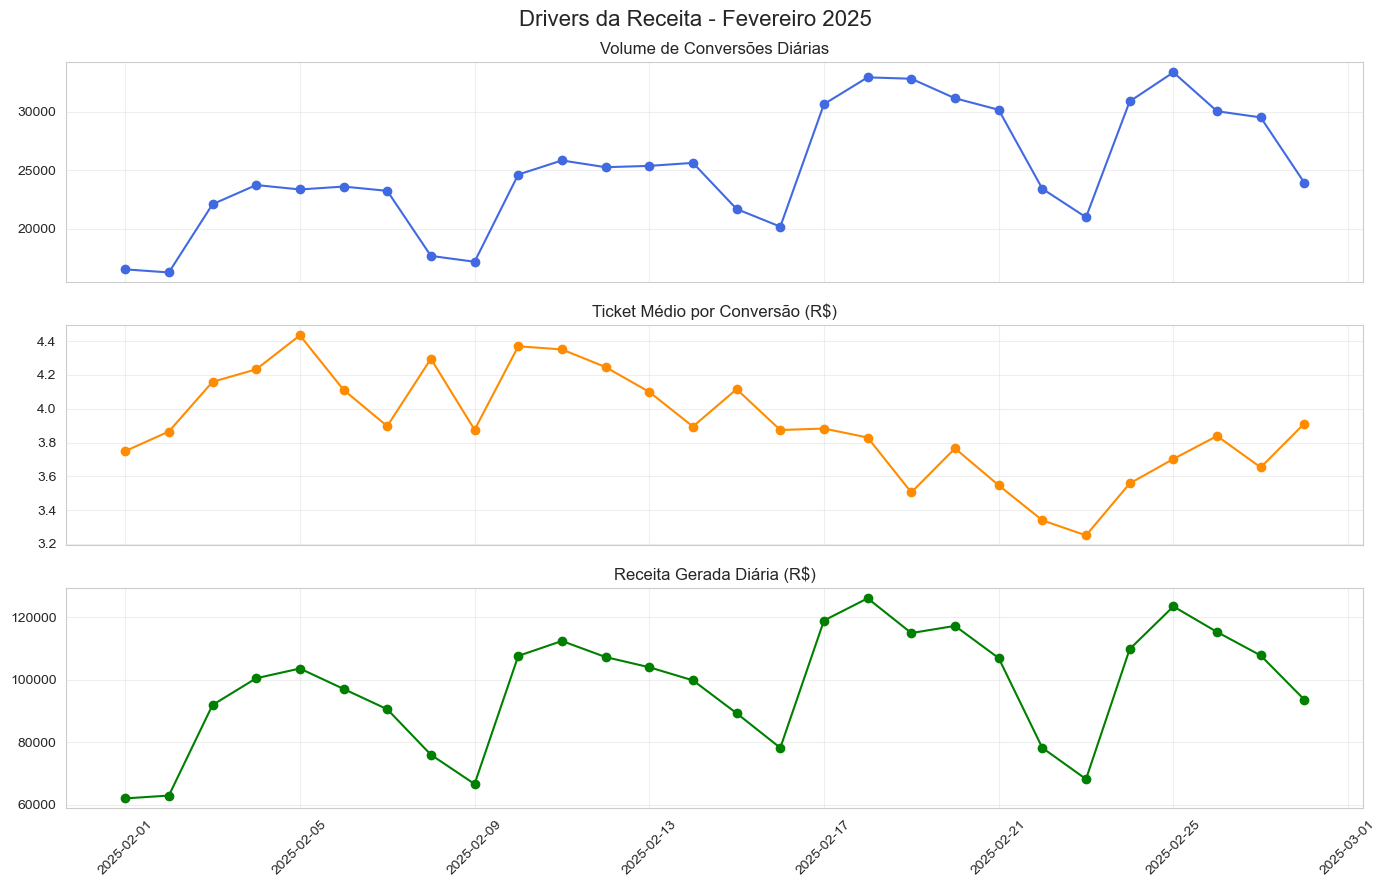

In [82]:
# ==================== ANÁLISE TEMPORAL + CORRELAÇÃO ====================

# Adiciona ticket médio diário
df_daily['ticket_medio'] = df_daily['receita_gerada'] / df_daily['convercao_efetiva']

# Correlação entre as variáveis
print("📊 Correlação entre variáveis diárias:")
print(df_daily[['convercao_efetiva', 'receita_gerada', 'ticket_medio']].corr().round(3))

# Plot combinado (os 3 drivers juntos)
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# 1. Conversões
axes[0].plot(df_daily['data'], df_daily['convercao_efetiva'], marker='o', color='royalblue')
axes[0].set_title('Volume de Conversões Diárias')
axes[0].grid(True, alpha=0.3)

# 2. Ticket Médio
axes[1].plot(df_daily['data'], df_daily['ticket_medio'], marker='o', color='darkorange')
axes[1].set_title('Ticket Médio por Conversão (R$)')
axes[1].grid(True, alpha=0.3)

# 3. Receita
axes[2].plot(df_daily['data'], df_daily['receita_gerada'], marker='o', color='green')
axes[2].set_title('Receita Gerada Diária (R$)')
axes[2].grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.suptitle('Drivers da Receita - Fevereiro 2025', fontsize=16)
plt.tight_layout()
plt.show()

Volume de conversões e Receita caminham juntos na maior parte do tempo, Correlação alta (como esperado).
Ticket médio cai quando o volume de conversões sobe:
    hipóteses:
        Quando você oferece mais volume (mais ofertas aceitas), o ticket médio cai.
        Quando o volume cai, o ticket médio sobe.
Taxa de conversão permanece estacionária (~3,8%) mesmo com variação grande no volume de ofertas/conversões

Você está expandindo a base de ofertas para um público com menor poder aquisitivo ou para produtos de menor valor (ex: crédito pessoal menor, digital-account com limite baixo, etc.).
Isso aumenta o volume de conversões, mas puxa o ticket médio para baixo
O fato da taxa de conversão não subir quando você oferece mais (ou produtos mais baratos) sugere que preço não é o principal driver de conversão nesse momento.
Ou seja: baratear o produto está trazendo mais volume, mas não está melhorando a eficiência do funil.

#### Analisando no $\mathbb{R}^3$

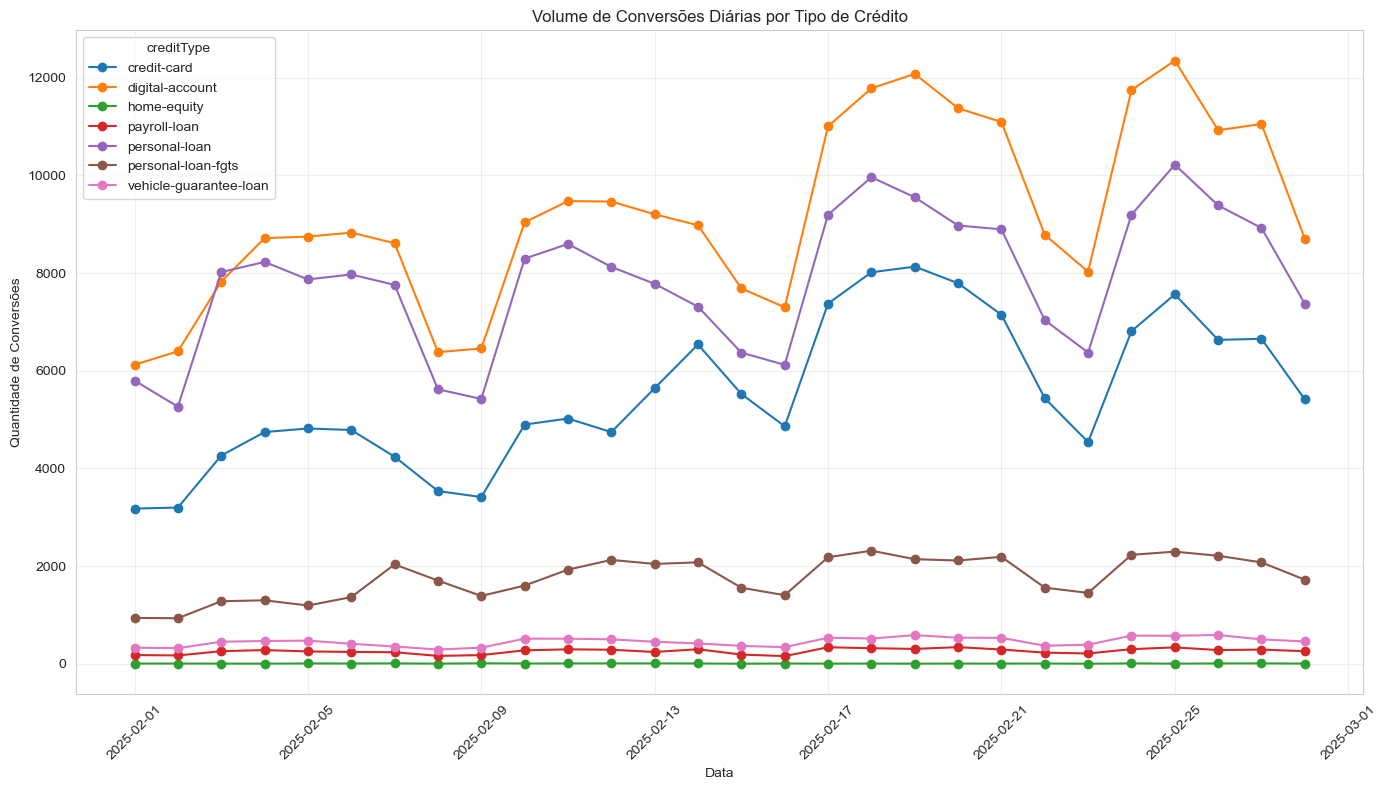

In [67]:
# Agrupando por data e creditType
df_daily_type = df.groupby(['data', 'creditType']).agg({
    'possui_oferta': 'sum',
    'convercao_efetiva': 'sum',
    'receita_gerada': 'sum'
}).reset_index()

df_daily_type['taxa_convercao'] = (df_daily_type['convercao_efetiva'] / df_daily_type['possui_oferta']) * 100
df_daily_type['ticket_medio']   = df_daily_type['receita_gerada'] / df_daily_type['convercao_efetiva']

# Gráfico de linhas para Volume de Conversões por creditType
plt.figure(figsize=(14, 8))
for credit in df_daily_type['creditType'].unique():
    subset = df_daily_type[df_daily_type['creditType'] == credit]
    plt.plot(subset['data'], subset['convercao_efetiva'], marker='o', label=credit)

plt.title('Volume de Conversões Diárias por Tipo de Crédito')
plt.xlabel('Data')
plt.ylabel('Quantidade de Conversões')
plt.legend(title='creditType')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Repita o mesmo para Ticket Médio (mude apenas a coluna para 'ticket_medio')

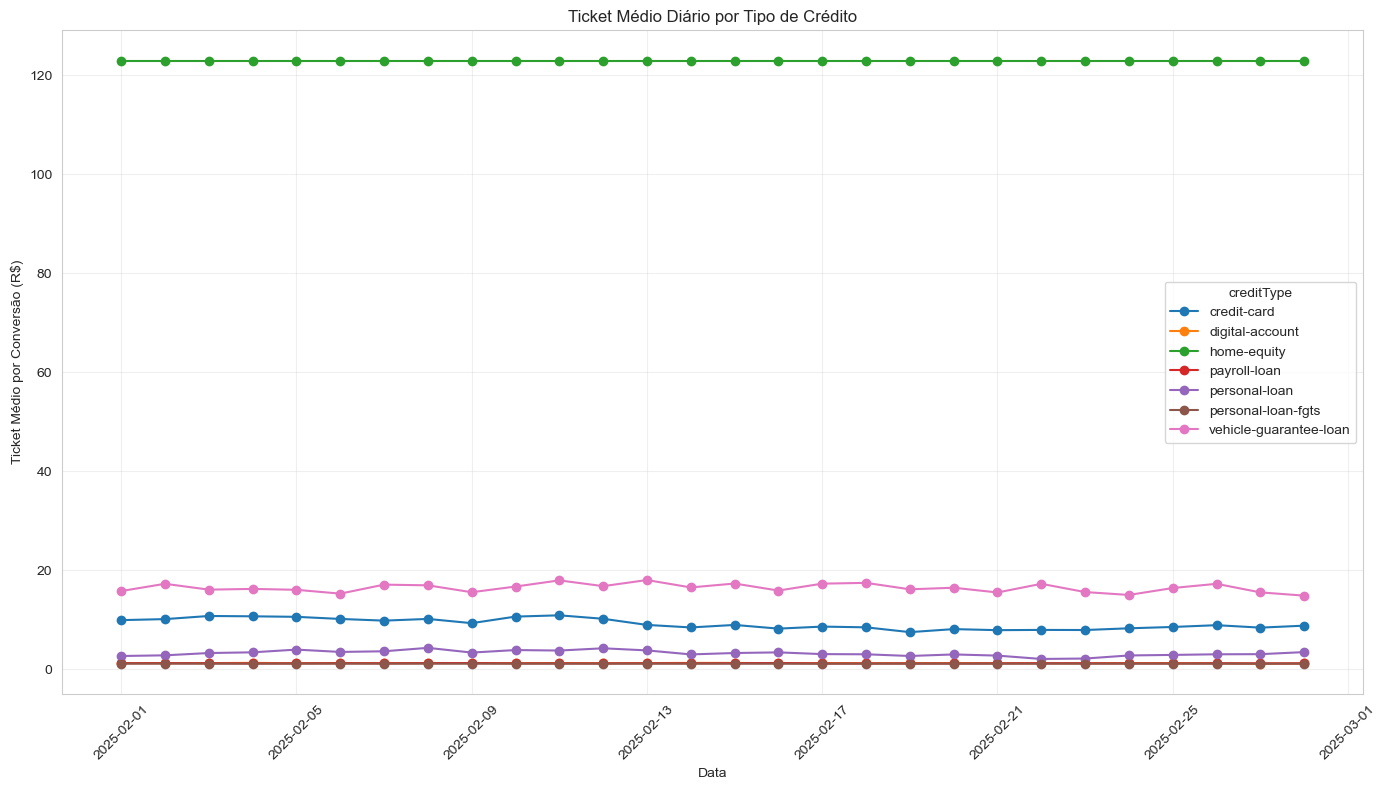

In [68]:
# Agrupando por data e creditType
df_daily_type = df.groupby(['data', 'creditType']).agg({
    'possui_oferta': 'sum',
    'convercao_efetiva': 'sum',
    'receita_gerada': 'sum'
}).reset_index()

df_daily_type['taxa_convercao'] = (df_daily_type['convercao_efetiva'] / df_daily_type['possui_oferta']) * 100
df_daily_type['ticket_medio']   = df_daily_type['receita_gerada'] / df_daily_type['convercao_efetiva']

# Gráfico de linhas para Ticket Médio por creditType
plt.figure(figsize=(14, 8))
for credit in df_daily_type['creditType'].unique():
    subset = df_daily_type[df_daily_type['creditType'] == credit]
    plt.plot(subset['data'], subset['ticket_medio'], marker='o', label=credit)

plt.title('Ticket Médio Diário por Tipo de Crédito')
plt.xlabel('Data')
plt.ylabel('Ticket Médio por Conversão (R$)')
plt.legend(title='creditType')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

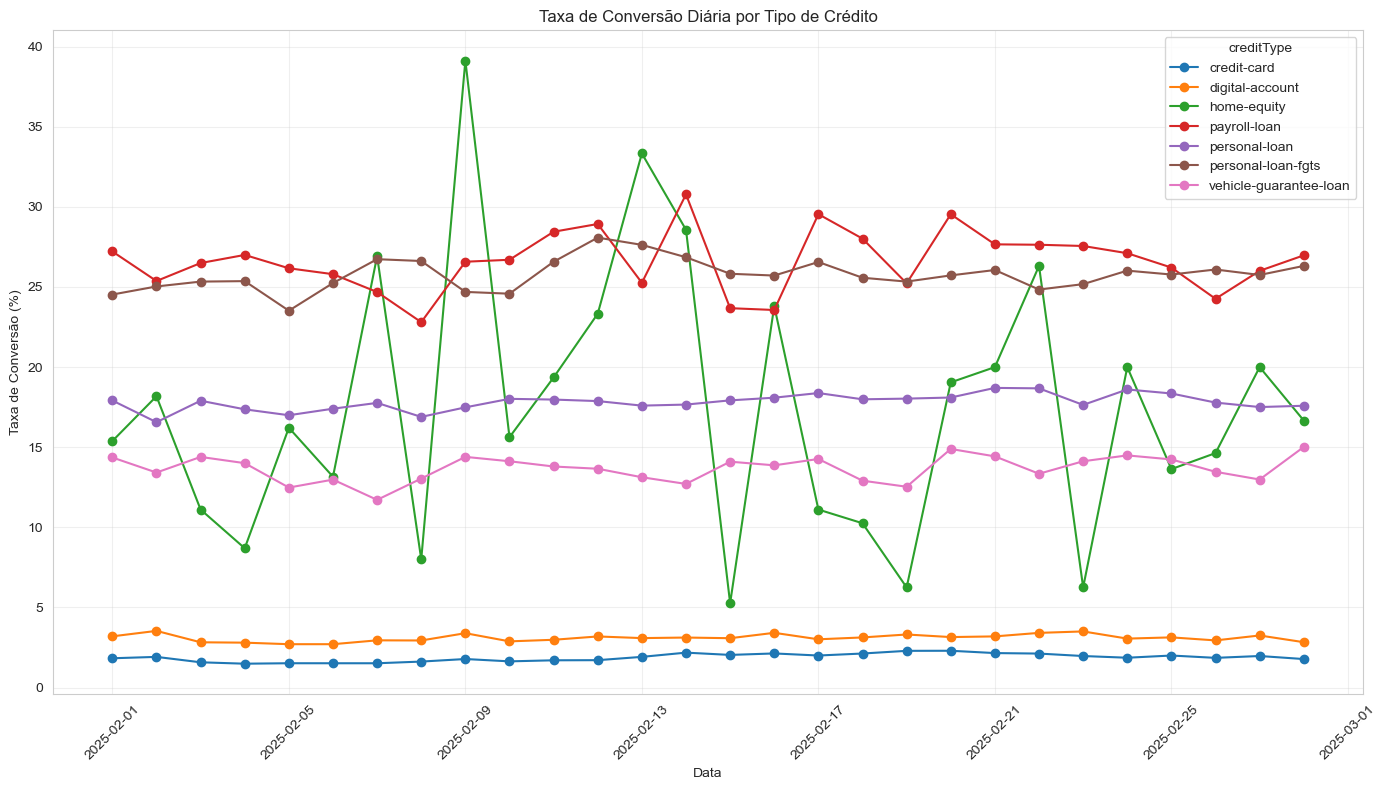

In [69]:
# Agrupando por data e creditType
df_daily_type = df.groupby(['data', 'creditType']).agg({
    'possui_oferta': 'sum',
    'convercao_efetiva': 'sum',
    'receita_gerada': 'sum'
}).reset_index()

df_daily_type['taxa_convercao'] = (df_daily_type['convercao_efetiva'] / df_daily_type['possui_oferta']) * 100
df_daily_type['ticket_medio']   = df_daily_type['receita_gerada'] / df_daily_type['convercao_efetiva']

# Gráfico de linhas para Volume de Conversões por creditType
plt.figure(figsize=(14, 8))
for credit in df_daily_type['creditType'].unique():
    subset = df_daily_type[df_daily_type['creditType'] == credit]
    plt.plot(subset['data'], subset['taxa_convercao'], marker='o', label=credit)

plt.title('Taxa de Conversão Diária por Tipo de Crédito')
plt.xlabel('Data')
plt.ylabel('Taxa de Conversão (%)')
plt.legend(title='creditType')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Resumo Estratégico por Tipo de Crédito

| creditType                  | Volume de Conversões     | Ticket Médio       | Taxa de Conversão     | Impacto na Receita                          | Recomendação Estratégica      |
|-----------------------------|--------------------------|--------------------|-----------------------|---------------------------------------------|-------------------------------|
| **digital-account**        | Muito alto (líder)      | Baixo             | Muito baixa (~3%)    | Alto volume, baixo valor                   | Manter volume / Otimizar preço |
| **credit-card**            | Alto                    | Baixo             | Baixíssima (~2%)     | Alto volume, baixo valor                   | Revisar oferta                |
| **personal-loan**          | Alto                    | Médio             | Média (~18%)         | Bom equilíbrio                             | Manter e expandir             |
| **home-equity**            | Quase zero              | **Muito alto (~122)** | Alta (~25-33%)     | **Altíssimo potencial**                    | **Aumentar oferta**           |
| **payroll-loan**           | Baixo                   | Médio             | Alta (~26-30%)       | Baixo volume                               | **Aumentar oferta**           |
| **personal-loan-fgts**     | Baixo-médio             | Muito baixo       | Alta (~25%)          | Baixo impacto                              | Avaliar rentabilidade         |

- Estamos crescendo volume com produtos baratos (digital-account + credit-card + personal-loan).
Eles respondem por grande parte das conversões absolutas, mas têm ticket médio baixo e taxa de conversão baixa.

- Os produtos com maior potencial de receita (home-equity, payroll-loan) têm taxa de conversão alta, mas quase não estão sendo ofertados (volume muito baixo e estável).

- Isso explica perfeitamente o trade-off que vimos antes:
    - ↑ Volume de conversões → ticket médio cai
    - Taxa de conversão geral fica estacionária em ~3,87%


Conclusão forte:
Estamos otimizando para volume, não para receita.
Estamos sacrificando ticket médio sem ganhar eficiência no funil (taxa de conversão não sobe).

In [83]:
# Rode isso depois de ter o df_daily_type
df_resumo_tipo = df.groupby('creditType').agg({
    'convercao_efetiva': 'sum',
    'receita_gerada': 'sum'
}).reset_index()

df_resumo_tipo['ticket_medio'] = df_resumo_tipo['receita_gerada'] / df_resumo_tipo['convercao_efetiva']
df_resumo_tipo['%_volume'] = df_resumo_tipo['convercao_efetiva'] / df_resumo_tipo['convercao_efetiva'].sum() * 100
df_resumo_tipo['%_receita'] = df_resumo_tipo['receita_gerada'] / df_resumo_tipo['receita_gerada'].sum() * 100

df_resumo_tipo.round(2)

,creditType,convercao_efetiva,receita_gerada,ticket_medio,%_volume,%_receita
0,credit-card,154900.0,1399411.5,9.03,22.07,51.26
1,digital-account,258128.0,326091.0,1.26,36.77,11.95
2,home-equity,129.0,15867.0,123.00,0.02,0.58
3,payroll-loan,7181.0,8830.5,1.23,1.02,0.32
4,personal-loan,219608.0,713703.0,3.25,31.29,26.14
5,personal-loan-fgts,49345.0,57268.5,1.16,7.03,2.10
6,vehicle-guarantee-loan,12668.0,208630.5,16.47,1.80,7.64


#### analisando dados no $\mathbb{R}^2$

##### Faixa etária

In [28]:
# analisando dados no \mathbb{R}^2
df_r2_faixa_etaria = df.groupby(['faixa_etaria']).agg({
    'total_users_simulando': 'sum',
    'usuario_elegivel': 'sum',
    'possui_oferta': 'sum',
    'convercao_efetiva': 'sum',
    'receita_gerada': 'sum'
}).reset_index()

In [29]:
df_r2_faixa_etaria

,faixa_etaria,total_users_simulando,usuario_elegivel,possui_oferta,convercao_efetiva,receita_gerada
0,0-20,7240983,1893747.0,510293.0,35259.0,86184.0
1,21-30,59736837,13273895.0,5716888.0,270213.0,764994.0
2,31-40,50898388,11748288.0,5830224.0,210696.0,868576.5
3,41-50,32983397,7617680.0,3850363.0,119248.0,634638.0
4,51-60,14588391,3361656.0,1715139.0,50498.0,289249.5
5,61-70,3590322,934911.0,456476.0,13687.0,74722.5
6,71-80,255967,95979.0,52564.0,2315.0,11271.0
7,80+,2053,1791.0,734.0,43.0,166.5


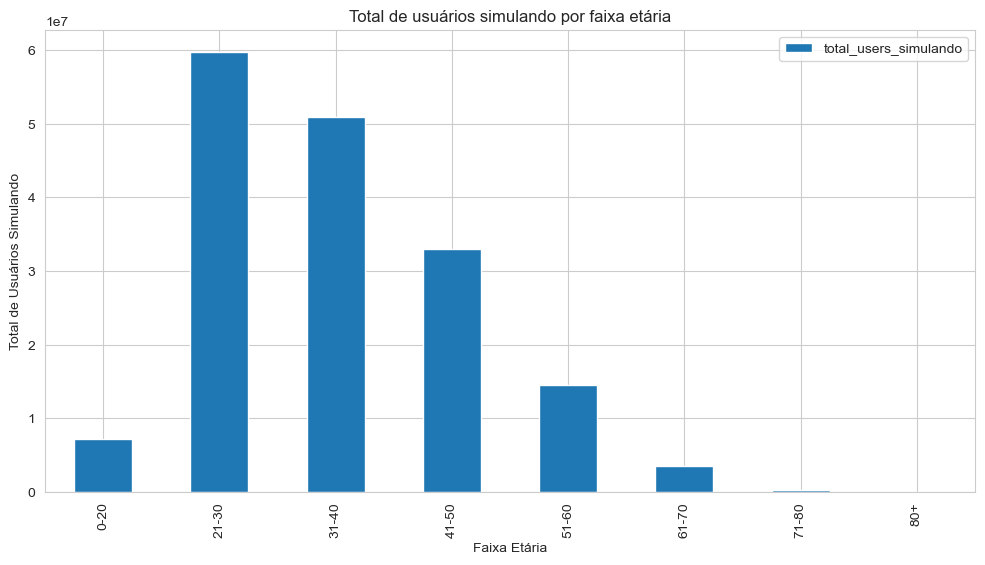

In [30]:
df_r2_faixa_etaria.plot(x='faixa_etaria', y='total_users_simulando', kind='bar')
plt.title('Total de usuários simulando por faixa etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Total de Usuários Simulando')
plt.show()

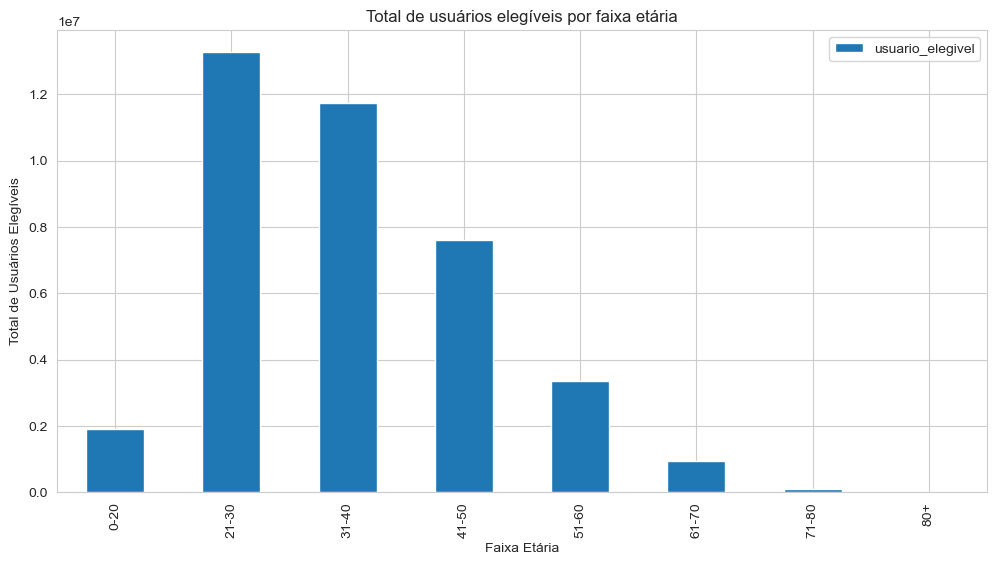

In [31]:
df_r2_faixa_etaria.plot(x='faixa_etaria', y='usuario_elegivel', kind='bar')
plt.title('Total de usuários elegíveis por faixa etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Total de Usuários Elegíveis')
plt.show()

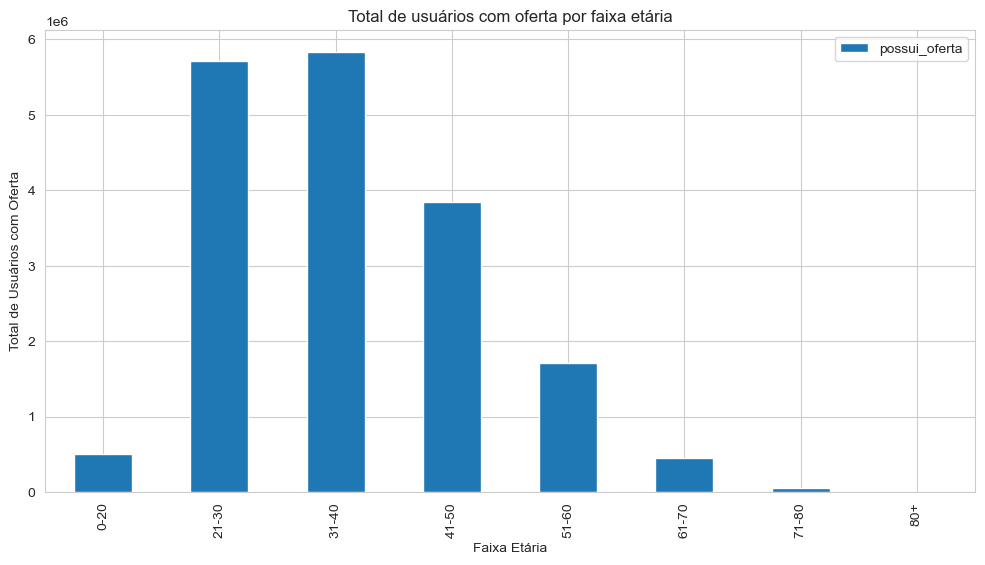

In [32]:
df_r2_faixa_etaria.plot(x='faixa_etaria', y='possui_oferta', kind='bar')
plt.title('Total de usuários com oferta por faixa etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Total de Usuários com Oferta')
plt.show()

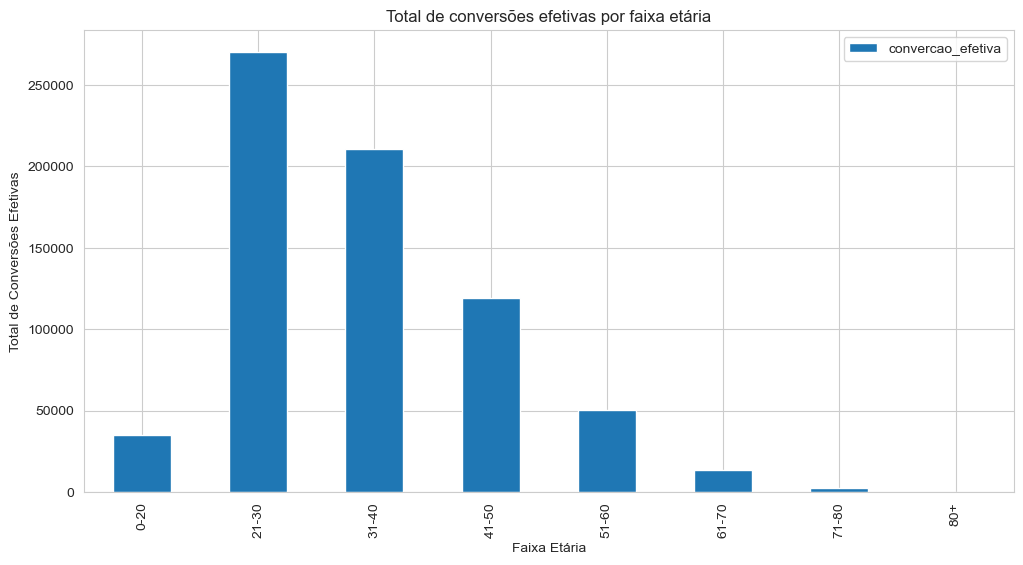

In [33]:
df_r2_faixa_etaria.plot(x='faixa_etaria', y='convercao_efetiva', kind='bar')
plt.title('Total de conversões efetivas por faixa etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Total de Conversões Efetivas')
plt.show()

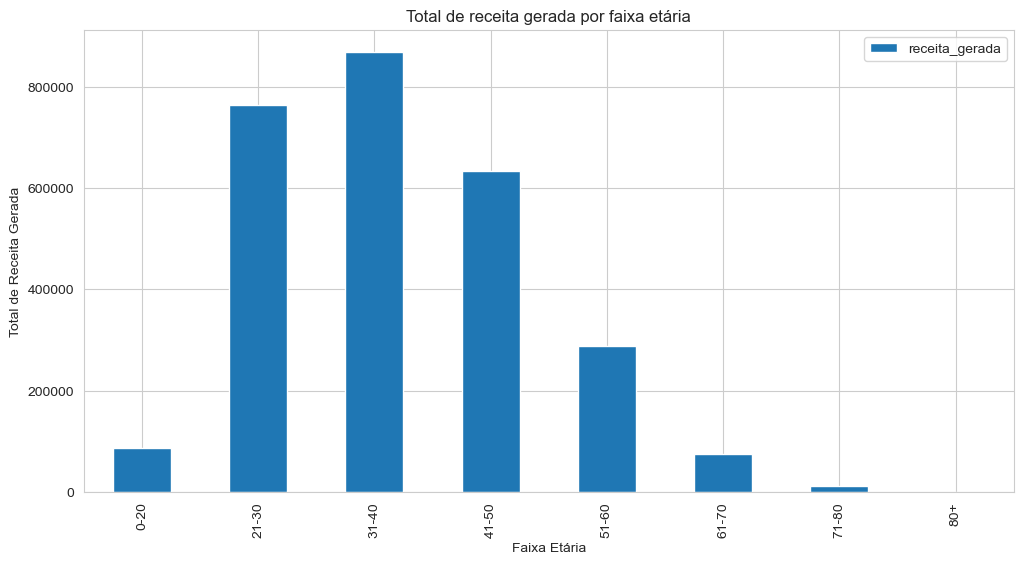

In [34]:
df_r2_faixa_etaria.plot(x='faixa_etaria', y='receita_gerada', kind='bar')
plt.title('Total de receita gerada por faixa etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Total de Receita Gerada')
plt.show()

analisando dados no $\mathbb{R}^2$ por faixa etária é possivel perceber que a faixa de 21-30 anos é a que mais simula, contudo os produtos são mais ofertados para a faixa de 31-40 anos, e é a que mais gera receita, pois tem mais crédito e provavelmente maiores salários, mas nsão mais críticos também em relação a fixa de 21-30 já que a taxa de aceitação de oferta é mais alta.

##### Faixas de renda

In [75]:
# ====================== R2 - ANÁLISE POR FAIXA DE RENDA ======================

# Primeiro, garantir que a coluna existe com o nome correto
print(df['fx_de_renda'].unique())   # ver os valores exatos

# Criar uma coluna auxiliar para ordenação correta
faixa_order = [
    '0-1600', '1601-2000', '2001-3000', '3001-4000', 
    '4001-5000', '5001-6000', '6001-7000', '7001-8000', 
    '8001-9000', '9001+'
]

# Converter para categoria ordenada
df['fx_de_renda'] = pd.Categorical(
    df['fx_de_renda'], 
    categories=faixa_order, 
    ordered=True
)

# Agora faz o groupby (R²)
df_r2_renda = df.groupby('fx_de_renda', observed=True).agg({
    'total_users_simulando': 'sum',
    'usuario_elegivel': 'sum',
    'possui_oferta': 'sum',
    'convercao_efetiva': 'sum',      # corrigido o nome da coluna (estava errado antes)
    'receita_gerada': 'sum'
}).reset_index()

# Mostrar resultado ordenado corretamente
display(df_r2_renda)

['0-1600', '4001-5000', '1601-2000', '7001-8000', '3001-4000', '9001+', '6001-7000', '2001-3000', '5001-6000', '8001-9000']
Categories (10, object): ['0-1600' < '1601-2000' < '2001-3000' < '3001-4000' ... '6001-7000' < '7001-8000' < '8001-9000' < '9001+']


,fx_de_renda,total_users_simulando,usuario_elegivel,possui_oferta,convercao_efetiva,receita_gerada
0,0-1600,76786574,16549752.0,6877823.0,386752.0,1028880.0
1,1601-2000,12557108,3002417.0,1372354.0,56899.0,215395.5
2,2001-3000,16663831,3937754.0,1909299.0,66265.0,290238.0
3,3001-4000,12104338,2937755.0,1456665.0,43029.0,229750.5
4,4001-5000,26353069,6076464.0,3217792.0,95027.0,458254.5
5,5001-6000,4192876,1138232.0,550347.0,12092.0,91680.0
6,6001-7000,3069402,846210.0,413519.0,8315.0,69864.0
7,7001-8000,2193946,621635.0,306555.0,5627.0,50682.0
8,8001-9000,1624909,471513.0,250420.0,4196.0,37930.5
9,9001+,13750285,3346215.0,1777907.0,23757.0,257127.0


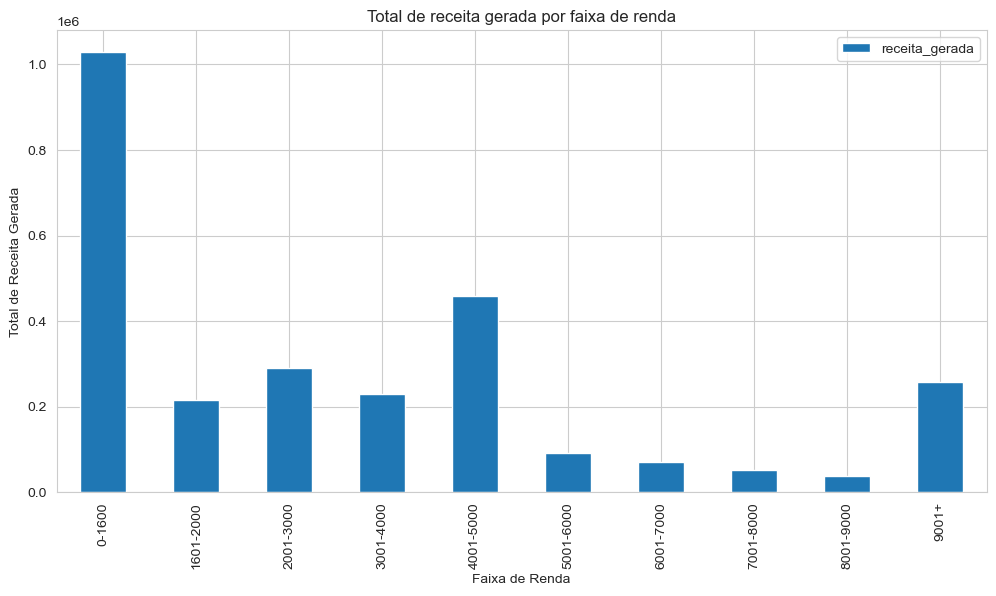

In [76]:
df_r2_renda.plot(x='fx_de_renda', y='receita_gerada', kind='bar')
plt.title('Total de receita gerada por faixa de renda')
plt.xlabel('Faixa de Renda')
plt.ylabel('Total de Receita Gerada')
plt.show()

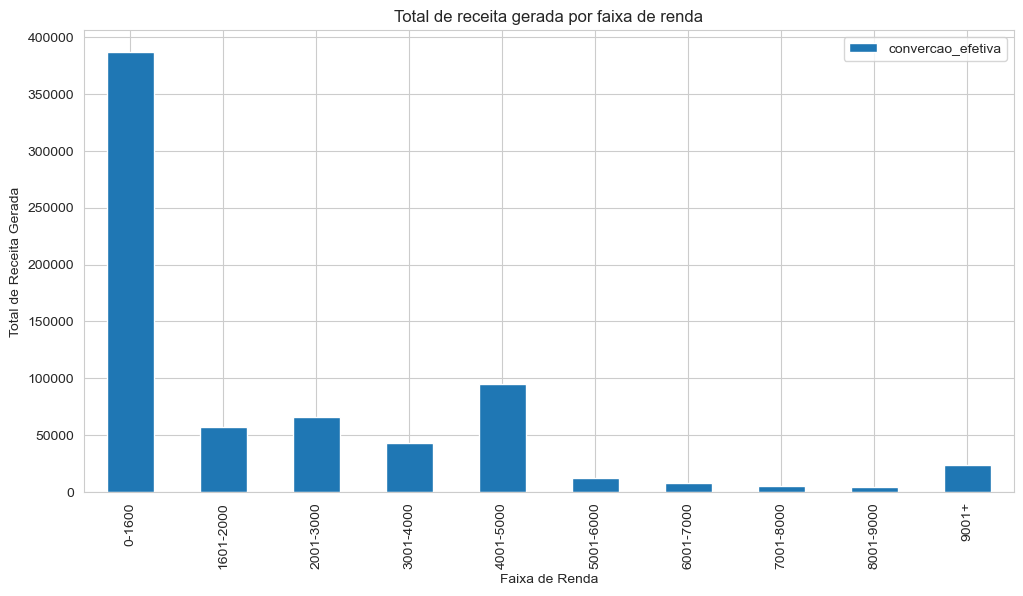

In [77]:
df_r2_renda.plot(x='fx_de_renda', y='convercao_efetiva', kind='bar')
plt.title('Total de receita gerada por faixa de renda')
plt.xlabel('Faixa de Renda')
plt.ylabel('Total de Receita Gerada')
plt.show()

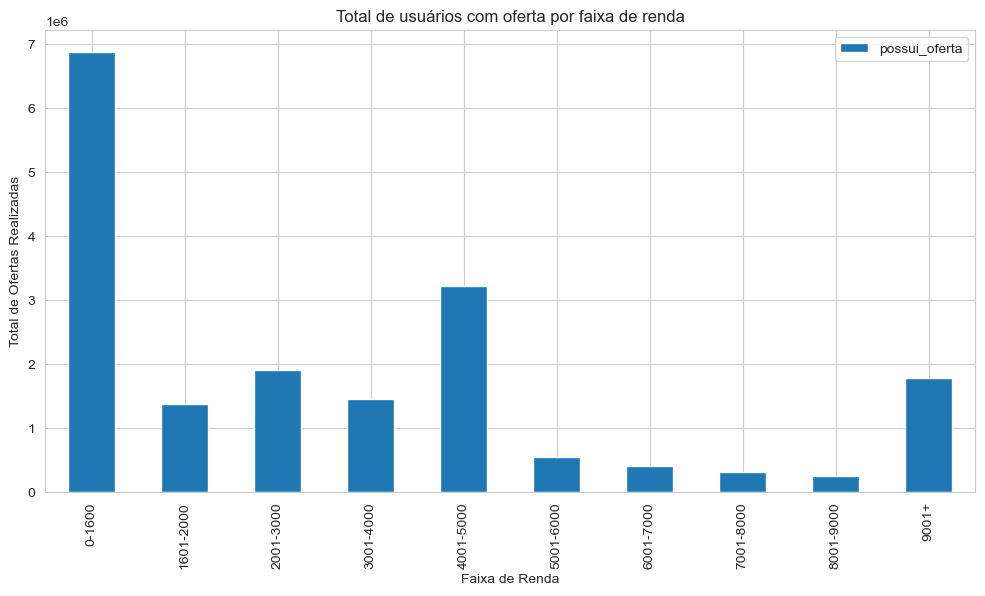

In [78]:
df_r2_renda.plot(x='fx_de_renda', y='possui_oferta', kind='bar')
plt.title('Total de usuários com oferta por faixa de renda')
plt.xlabel('Faixa de Renda')
plt.ylabel('Total de Ofertas Realizadas')
plt.show()

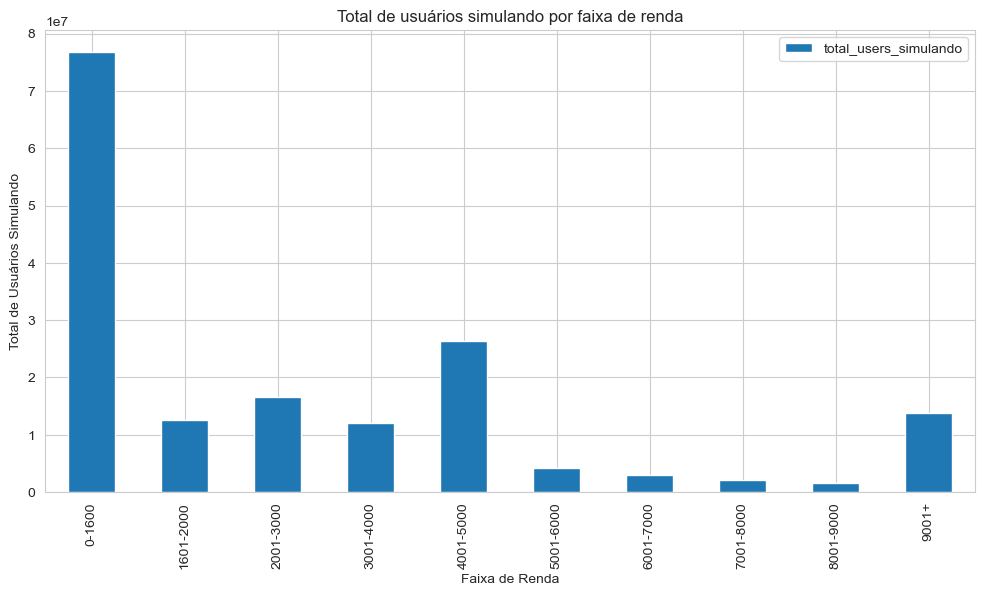

In [79]:
df_r2_renda.plot(x='fx_de_renda', y='total_users_simulando', kind='bar')
plt.title('Total de usuários simulando por faixa de renda')
plt.xlabel('Faixa de Renda')
plt.ylabel('Total de Usuários Simulando')
plt.show()

### Inconsistência Identificada - Outlier na Faixa de Renda

Ao analisar o volume de simulações por faixa de renda, observamos um **outlier extremo** na faixa **0-1600**, que concentra mais de 50% de todas as simulações do mês (aproximadamente 76 milhões).

**Contexto importante:**
- O produto "personal-loan-fgts" (principal driver esperado para essa faixa) só foi anunciado em **março de 2025**.
- Os dados analisados referem-se a **fevereiro de 2025**.

Essa discrepância sugere que o alto volume na faixa de baixa renda é um **artefato do dataset sintético** gerado para o case, provavelmente por injeção artificial de simulações de FGTS.

**Decisão de análise:**
- Vamos apresentar os resultados **com** e **sem** a faixa 0-1600 para transparência.
- A análise principal será feita excluindo esse outlier, destacando a limitação dos dados.

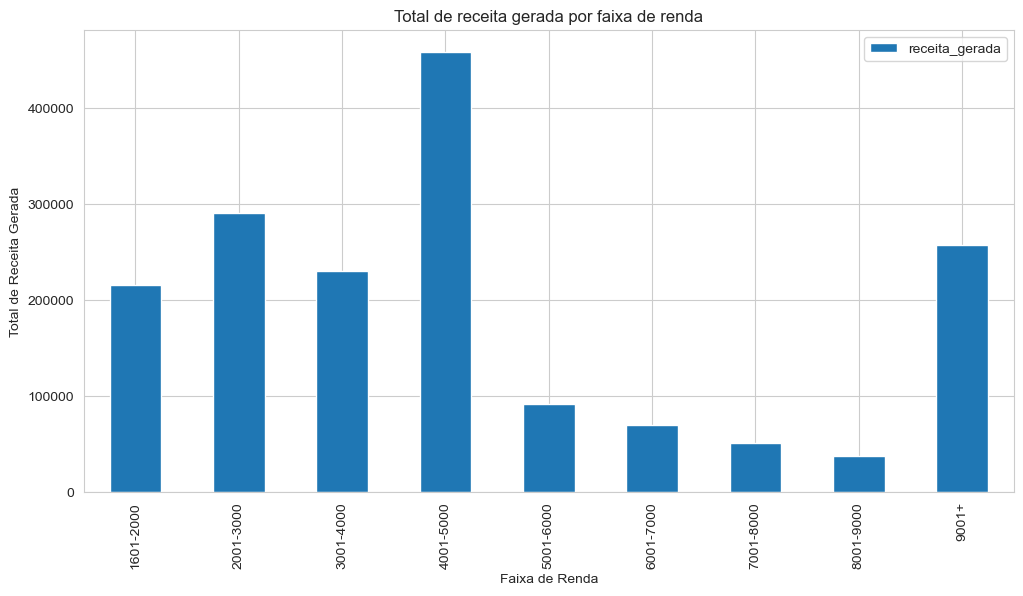

In [80]:
df_r2_renda[df_r2_renda['fx_de_renda']!='0-1600'].plot(x='fx_de_renda', y='receita_gerada', kind='bar')
plt.title('Total de receita gerada por faixa de renda')
plt.xlabel('Faixa de Renda')
plt.ylabel('Total de Receita Gerada')
plt.show()

In [84]:
cols = ['convercao_efetiva', 'receita_gerada']

for c in cols:
    s = df[c]
    pct_zero = (s == 0).mean() * 100
    print(f"\n=== {c} ===")
    print(f"% de zeros: {pct_zero:.2f}%")
    print("Percentis (50, 75, 90, 95, 99):")
    print(s.quantile([0.50, 0.75, 0.90, 0.95, 0.99]).to_string())

# distribuição apenas dos valores positivos (evita o efeito da massa em zero)
for c in cols:
    s_pos = df.loc[df[c] > 0, c]
    print(f"\n--- {c} (somente > 0) ---")
    if len(s_pos) == 0:
        print("Sem valores positivos")
    else:
        print(s_pos.quantile([0.50, 0.75, 0.90, 0.95, 0.99]).to_string())


=== convercao_efetiva ===
% de zeros: 51.64%
Percentis (50, 75, 90, 95, 99):
0.50      0.0
0.75      3.0
0.90     13.0
0.95     29.0
0.99    111.0

=== receita_gerada ===
% de zeros: 57.37%
Percentis (50, 75, 90, 95, 99):
0.50      0.0
0.75      7.5
0.90     52.5
0.95    135.0
0.99    448.5

--- convercao_efetiva (somente > 0) ---
0.50      3.00
0.75     10.00
0.90     29.00
0.95     53.00
0.99    191.06

--- receita_gerada (somente > 0) ---
0.50     12.0
0.75     49.5
0.90    157.5
0.95    291.0
0.99    721.5
